# Importing Libraries

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [3]:
dataset_path = "dataset"

# Splitting the dataset into training and validation data

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 12000 files belonging to 12 classes.
Using 9600 files for training.
Found 12000 files belonging to 12 classes.
Using 2400 files for validation.


In [6]:
class_names = train_ds.class_names
class_names

['caesar_salad',
 'chocolate_cake',
 'edamame',
 'french_fries',
 'fried_rice',
 'greek_salad',
 'grilled_salmon',
 'hamburger',
 'ice_cream',
 'omelette',
 'pizza',
 'sushi']

# Normalize the images

In [8]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x),y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x),y))

# Load the pretrained model MobileNetV2

In [11]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# Data Augmentation

In [25]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Build Classification Model

In [27]:
model = keras.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

# Compile model

In [28]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model

In [29]:
history = model.fit(
    train_ds, 
    validation_data = val_ds,
    epochs=10
)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 145s 312ms/step - accuracy: 0.6726 - loss: 1.0330 - val_accuracy: 0.8067 - val_loss: 0.6146
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 98s 327ms/step - accuracy: 0.7719 - loss: 0.7176 - val_accuracy: 0.8221 - val_loss: 0.5505
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 85s 282ms/step - accuracy: 0.7903 - loss: 0.6557 - val_accuracy: 0.8379 - val_loss: 0.5221
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 86s 285ms/step - accuracy: 0.8006 - loss: 0.6124 - val_accuracy: 0.8392 - val_loss: 0.5123
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 99s 329ms/step - accuracy: 0.8133 - loss: 0.5685 - val_accuracy: 0.8375 - val_loss: 0.5213
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 105s 350ms/step - accuracy: 0.8213 - loss: 0.5333 - val_accuracy: 0.8429 - val_loss: 0.5091
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 87s 289ms/step - accuracy: 0.8328 - loss: 0.5073 - val_accuracy: 0.8333 - val_loss: 0.5193
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 113s 375ms/step - accuracy: 0.8298 - loss

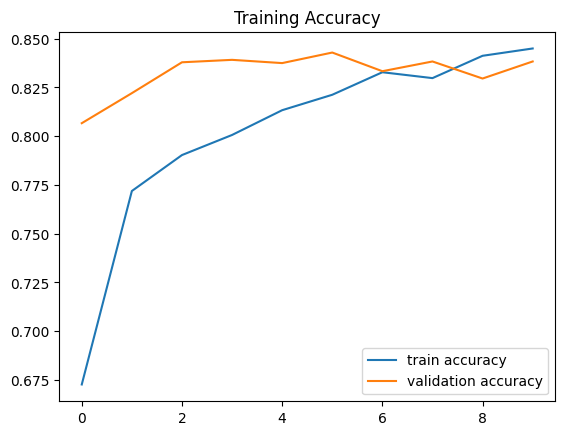

In [30]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.title("Training Accuracy")
plt.show()

# Save the model

In [31]:
model.save("food_detection_model.h5")

In [1]:
import numpy as np
from PIL import Image

img = Image.open("pizza.jpg").resize((224,224))
img_array = np.array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Food:", predicted_class)

NameError: name 'model' is not defined